# VIX Curve Relative Value (Level-Neutral) — Results

Short the 30-day constant-maturity VIX future against a minimum-norm long basket across
60–180 days, weighted to be orthogonal to the curve's level factor (~97% of variance);
re-derived every five sessions; always on. The harvest is the curve's shape premium —
roll-down plus curvature — not a vol-direction bet: the book made money through every
panic in the sample (2018, 2020, Aug-2024, Apr-2025) while its losses concentrate in
low-VIX, steep-contango grinds.

*2016-05 → 2025-11, in-sample; a previously advertised sizing overlay was retired after
an alignment repair (it added nothing); the base book is the card.*

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import datetime
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
D = Path('data')

def sh(x, ann=252):
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    return float(x.mean()/x.std()*np.sqrt(ann))

pl.Config.set_tbl_cols(-1); pl.Config.set_tbl_width_chars(200)
pl.Config.set_tbl_hide_dataframe_shape(True)
plt.rcParams.update({'figure.dpi': 96, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})
pnl = pl.read_parquet(D/'daily_pnl.parquet').sort('tradingDay')
att = pl.read_parquet(D/'attr_carry.parquet').sort('tradingDay')
x = pnl['strategy_ret'].drop_nulls().to_numpy()
print(f"{pnl['tradingDay'].min()} -> {pnl['tradingDay'].max()} ({len(x)} days) | "
      f"base Sharpe {sh(x):+.2f} | ann ~{x.mean()*252:.0%} at ~{x.std()*np.sqrt(252):.0%} vol")

2016-05-13 -> 2025-11-03 (2401 days) | base Sharpe +1.55 | ann ~31% at ~20% vol


## 1. Performance and the carry engine

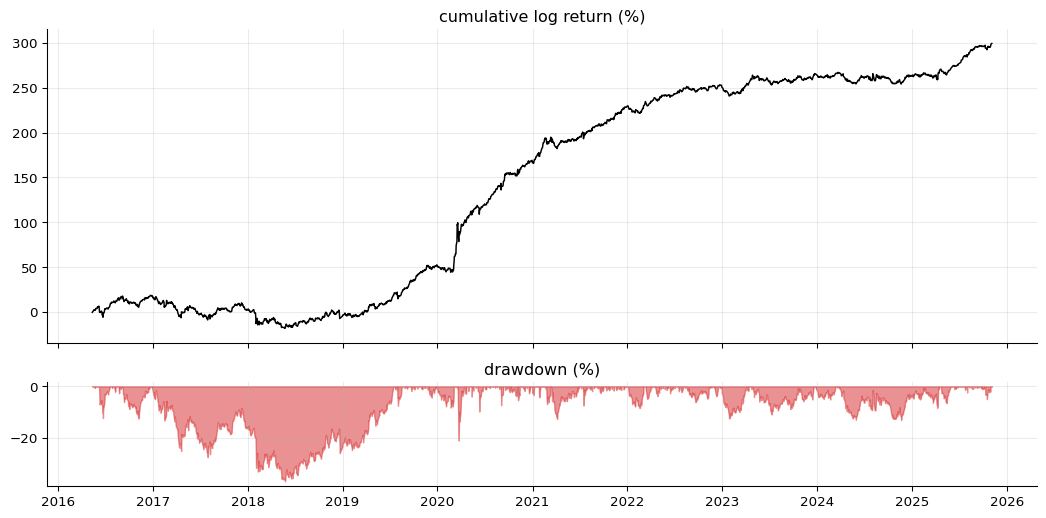

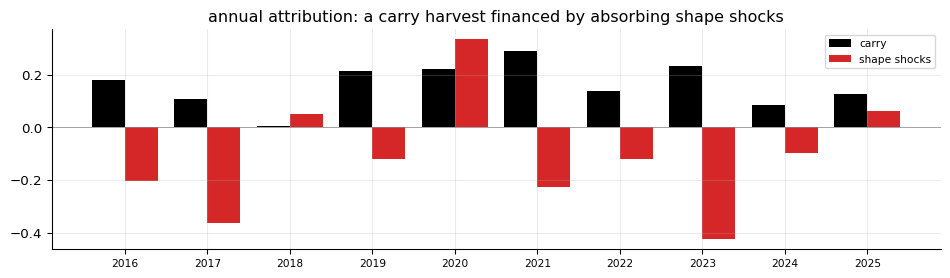

carry is 3.3x the total; shocks drag the difference. Worst episode: -31% over 2016-12 -> 2018-05 (low-VIX steep contango), 358 sessions under water — panics are fine, grinds are the poison.


In [2]:
p = pnl.with_columns(eq=pl.col('strategy_ret').cum_sum())
fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True,
                       gridspec_kw={'height_ratios': [3, 1]})
ax[0].plot(p['tradingDay'], p['eq']*100, 'k', lw=1.1)
ax[0].set_title('cumulative log return (%)')
runmax = np.maximum.accumulate(p['eq'].to_numpy())
ax[1].fill_between(p['tradingDay'], (p['eq'].to_numpy()-runmax)*100, 0, color='tab:red', alpha=0.5)
ax[1].set_title('drawdown (%)')
plt.tight_layout(); plt.show()
a = att.with_columns(y=pl.col('tradingDay').dt.year())
ann = a.group_by('y').agg(carry=pl.col('port_carry').sum(), shock=(pl.col('port_total')-pl.col('port_carry')).sum()).sort('y')
xx = np.arange(ann.height)
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(xx-0.2, ann['carry'], 0.4, label='carry', color='k')
ax.bar(xx+0.2, ann['shock'], 0.4, label='shape shocks', color='tab:red')
ax.set_xticks(xx, ann['y'], fontsize=8); ax.legend(fontsize=8); ax.axhline(0, c='gray', lw=0.5)
ax.set_title('annual attribution: a carry harvest financed by absorbing shape shocks')
plt.tight_layout(); plt.show()
print(f"carry is {float(att['port_carry'].sum())/float(att['port_total'].sum()):.1f}x the total; "
      f"shocks drag the difference. Worst episode: -31% over 2016-12 -> 2018-05 (low-VIX steep"
      f" contango), 358 sessions under water — panics are fine, grinds are the poison.")

## Luck check — is the realized P&L distinguishable from chance?

Two bootstrap questions. **The luck band**: 10,000 stationary-block resamples of the
realized unit returns — the spread of outcomes this stream could have delivered, and how
often such a path loses money. **The zero-edge null**: demean the units (same volatility,
no edge) — how often pure luck reaches the realized total. The first shows the width of
fortune; the second is the p-value for "it's all luck".

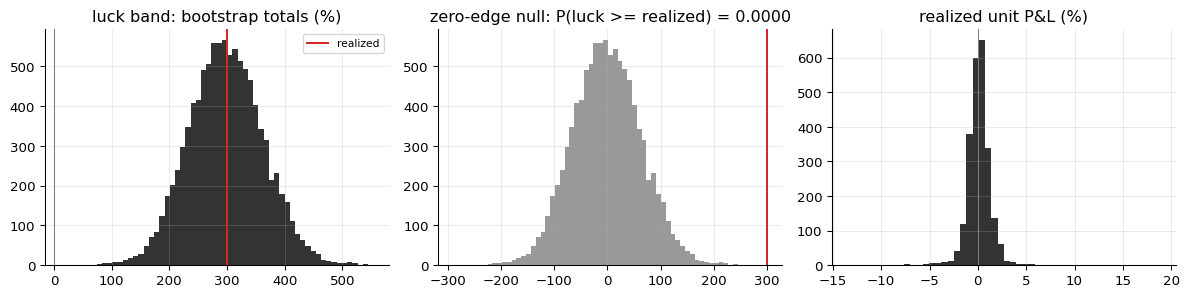

realized +299.3 | luck band 5th-95th [+195.5, +403.9] % | P(path loses) = 0.00% | zero-edge p = 0.0000


In [3]:
def _block_boot(x, n_boot=10000, mean_block=3, seed=7):
    rng = np.random.default_rng(seed)
    n = len(x); p = 1.0/mean_block
    tot = np.empty(n_boot)
    for b in range(n_boot):
        idx = np.empty(n, dtype=int)
        i = rng.integers(n)
        for k in range(n):
            idx[k] = i
            i = rng.integers(n) if rng.random() < p else (i + 1) % n
        tot[b] = x[idx].sum()
    return tot

_x = np.asarray(pnl['strategy_ret'].drop_nulls(), float); _x = _x[~np.isnan(_x)]
_real = _x.sum(); _tot = _block_boot(_x); _null = _block_boot(_x - _x.mean())
_p = float((_null >= _real).mean())
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.2))
ax[0].hist(_tot*100, bins=60, color='k', alpha=0.8)
ax[0].axvline(_real*100, c='tab:red', lw=1.5, label='realized')
ax[0].axvline(0, c='gray', lw=0.8); ax[0].legend(fontsize=8)
ax[0].set_title('luck band: bootstrap totals (%)')
ax[1].hist(_null*100, bins=60, color='gray', alpha=0.8)
ax[1].axvline(_real*100, c='tab:red', lw=1.5)
ax[1].set_title(f'zero-edge null: P(luck >= realized) = {_p:.4f}')
ax[2].hist(_x*100, bins=50, color='k', alpha=0.8)
ax[2].axvline(0, c='gray', lw=0.8); ax[2].set_title('realized unit P&L (%)')
plt.tight_layout(); plt.show()
print(f"realized {_real*100:+,.1f} | luck band 5th-95th "
      f"[{np.percentile(_tot,5)*100:+,.1f}, {np.percentile(_tot,95)*100:+,.1f}] % | "
      f"P(path loses) = {(_tot<0).mean():.2%} | zero-edge p = {_p:.4f}")

## 2. Conclusions

- A real, reproducible ~1.5-Sharpe in-sample shape-premium harvest with clean crash
  behavior and a known, regime-specific failure mode; positive skew means higher-moment
  adjustments barely dent it.
- Not sized yet by design: costs (spread tiers take net to ~1.5/1.3/1.0), a
  walk-forward-validated gate, and a tail policy for the kurtosis are the gates — all
  measured and registered.
- The realized total clears the zero-edge null; the luck band shows what a holder of
  this stream should expect.

*Private: the weight construction and window provenance, the rejected-knob research
(vol targeting, carry sizing, state machines), cost/capacity studies.*